# Data Exploration

Basic data exploration for better understanding of the data
Google colab: https://colab.research.google.com/drive/17_PbPW78Fpik3U_NUBG_-OCaW13YAyug?usp=sharing

## Data loading

In [ ]:
from data.data_loader import DataLoader
data_loader = DataLoader("data/raw/finefoods.txt")
data = data_loader.load()
data.head()

Parsing line: 5116093it [00:03, 1542872.25it/s]


,productId,userId,profileName,helpfulness,score,time,summary,text
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1/1,5.0,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0/0,1.0,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1/1,4.0,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3/3,2.0,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0/0,5.0,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Helpfulness might be converted to some other format but as it is not used for the task, I ignore it.

In [ ]:
data.shape

(568454, 8)

In [ ]:
data.score = data.score.astype(float) # set proper dtype

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   productId    568454 non-null  object 
 1   userId       568454 non-null  object 
 2   profileName  568454 non-null  object 
 3   helpfulness  568454 non-null  object 
 4   score        568454 non-null  float64
 5   time         568454 non-null  object 
 6   summary      568454 non-null  object 
 7   text         568454 non-null  object 
dtypes: float64(1), object(7)
memory usage: 34.7+ MB


## Feature Exploration

In [ ]:
column = "productId" #@param ["productId",	"userId",	"profileName",	"helpfulness", "time"]
data[column].value_counts()

,count
productId,
B007JFMH8M,913
B002QWP89S,632
B0026RQTGE,632
B002QWHJOU,632
B002QWP8H0,632
...,...
B004CHDG44,1
B004CZUOSM,1
B009GTIHG0,1


In [ ]:
data[column].describe()

,productId
count,568454
unique,74258
top,B007JFMH8M
freq,913


## Analysis of input features - Text & Summary

In [ ]:
def word_tokenize(text: str) -> list[str]:
  """Simple tokenizer for quick text length analysis, returns rough list of words."""
  return text.strip().lower().split()

def char_tokenize(text: str) -> list[str]:
  """Simple tokenizer for quick text length analysis, returns rough list of chars."""
  return list(text.strip().lower())

In [ ]:
input_feature =  "summary" #@param ["text", "summary"]
unit = "word" #@param ["word", "char"]
tokenize = word_tokenize if unit == "word" else char_tokenize
data["text_length"] = data[input_feature].apply(lambda x: len(tokenize(x)))
data["text_length"].describe()

,text_length
count,568454.000000
mean,4.113149
std,2.597340
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,42.000000


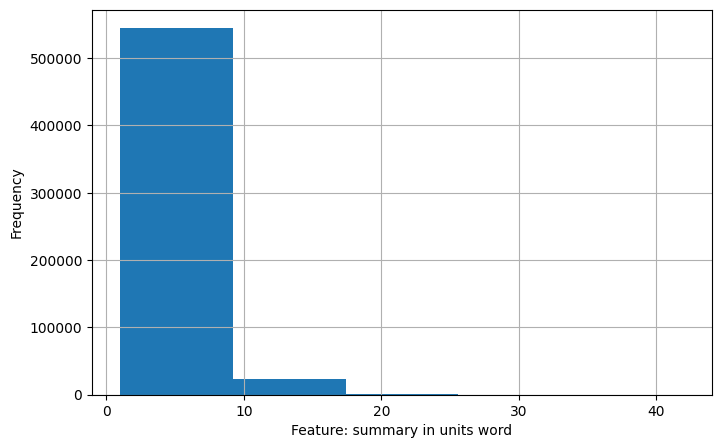

In [ ]:
import math
import matplotlib.pyplot as plt
number_of_bins = int(math.sqrt(len(data["text_length"].value_counts())))
data["text_length"].hist(bins=number_of_bins, figsize=(8, 5))
plt.xlabel(f'Feature: {input_feature} in units {unit}')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

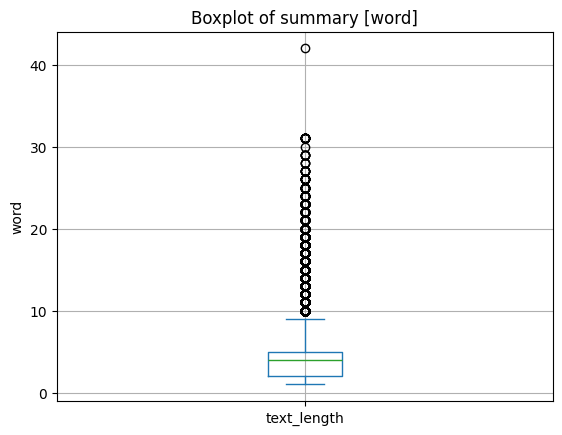

In [ ]:
data["text_length"].plot.box()
plt.title(f'Boxplot of {input_feature} [{unit}]')
plt.ylabel(f'{unit}')
plt.grid(True)
plt.show()

Are there differences between texts solely based on length?

In [ ]:
desc_stats = data.groupby('score')['text_length'].describe()
print(desc_stats)

          count      mean       std  min  25%  50%  75%   max
score                                                        
1.0     52268.0  4.281052  2.840864  1.0  2.0  4.0  6.0  29.0
2.0     29769.0  4.488528  2.737228  1.0  2.0  4.0  6.0  27.0
3.0     42640.0  4.756567  2.819221  1.0  3.0  4.0  6.0  26.0
4.0     80655.0  4.420594  2.729330  1.0  2.0  4.0  6.0  31.0
5.0    363122.0  3.914365  2.464230  1.0  2.0  3.0  5.0  42.0


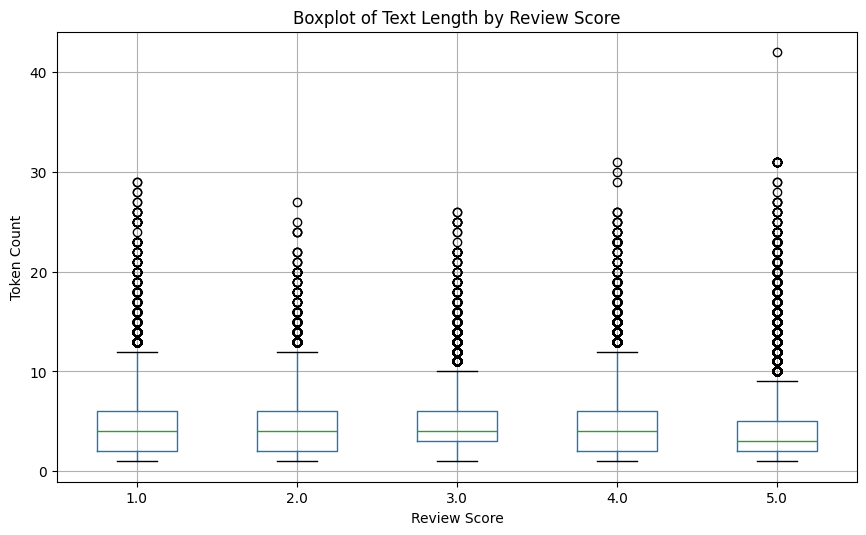

In [ ]:
data.boxplot(column='text_length', by='score', figsize=(10, 6))
plt.title('Boxplot of Text Length by Review Score')
plt.suptitle('')  # Removes automatic "Boxplot grouped by score"
plt.xlabel('Review Score')
plt.ylabel('Token Count')
plt.grid(True)
plt.show()

Checking normality

In [ ]:
from scipy.stats import shapiro, kruskal, probplot
for score, group in data.groupby('score'):
    stat, p = shapiro(group['text_length'])
    print(f"Score {score}: W={stat:.4f}, p={p:.4e} --> {'Non-normal' if p < 0.05 else 'Normal'}")

Score 1.0: W=0.8802, p=1.4128e-102 --> Non-normal
Score 2.0: W=0.9056, p=4.2199e-84 --> Non-normal
Score 3.0: W=0.9103, p=9.7708e-91 --> Non-normal
Score 4.0: W=0.8802, p=1.8668e-112 --> Non-normal
Score 5.0: W=0.8672, p=2.5862e-147 --> Non-normal


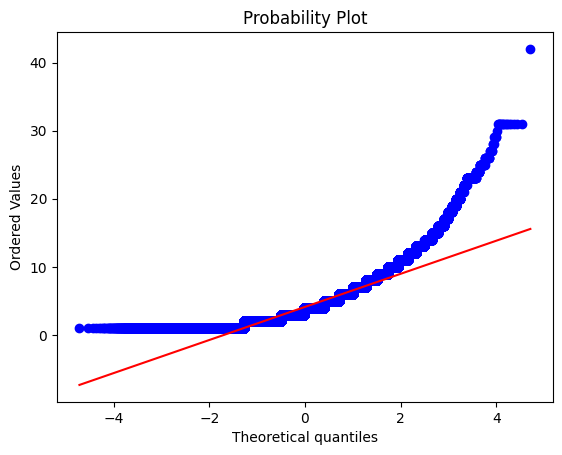

In [ ]:
probplot(data['text_length'], dist="norm", plot=plt)
plt.show()

let's do non parametric (the data inside groups is not normally distributed)

In [ ]:
groups = [group['text_length'].values for _, group in data.groupby('score')]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("At alpha=0.05, at least 1 group is different")
else:
    print("No evidence of difference between groups.")


Kruskal-Wallis H-statistic: 6481.9694
P-value: 0.0000e+00
At alpha=0.05, at least 1 group is different




1.   Length of **column text** (measured in words and chars) seems **to have effect** on sentiment score  
2.   Length of **column summary** (measured in words and chars) seems **to have effect** on sentiment score

This might be basis for a very simple model, say Decision tree. Also there's quite a few outliers, which might be left out or further studied.



## Analysis of predicted feature - Score

In [ ]:
data["score"].describe()

,score
count,568454.000000
mean,4.183199
std,1.310436
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
data["score"].value_counts()

,count
score,
5.0,363122
4.0,80655
1.0,52268
3.0,42640
2.0,29769


The distribution is skewed, might use downsampling or oversampling in model creation.